# HEROS Phase 4: Advanced Analytics

**Chinatown HEROS Project — Environmental Health Analysis**

Phase 4 applies advanced analytical techniques beyond the Q1–Q9 research questions:

1. **K-means clustering** — Cluster sites by environmental profile
2. **Regression deep-dive** — Non-linear and quantile regression
3. **Principal Component Analysis** — Dimensionality reduction of environmental variables
4. **Spatial analysis** — Interactive Folium maps of site-level statistics
5. **Change-point detection** — Identify regime shifts (wildfire smoke, heat waves)
6. **Anomaly detection** — Flag unusual readings
7. **Sankey rank diagrams** — Compare site rankings across PM2.5 vs WBGT
8. **Environmental Justice framing** — Contrast with EPA NAAQS and OSHA thresholds

---

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest
import json
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 300, 'font.size': 10})
sns.set_style('whitegrid')

ROOT = Path('../../')
DATA = ROOT / 'data/clean/data_HEROS_clean.parquet'
FIG_DIR = ROOT / 'figures/phase4'
REPORT_DIR = ROOT / 'reports/phase4'
FIG_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(DATA)
print(f'Dataset: {df.shape[0]:,} rows x {df.shape[1]} cols')
print(f'Sites: {sorted(df.site_id.unique())}')
print(f'Period: {df.datetime.min()} to {df.datetime.max()}')

PM = 'pa_mean_pm2_5_atm_b_corr_2'
WBGT = 'kes_mean_wbgt_f'
TEMP = 'kes_mean_temp_f'
HUMID = 'kes_mean_humid_pct'
WIND = 'mean_wind_speed_mph'
WDIR = 'wind_direction_degrees_kr'

LANDUSE_COLS = [c for c in df.columns if 'Area_Percent' in c]
ENV_COLS = [PM, WBGT, TEMP, HUMID, WIND]

# Site coordinates (from project documentation)
SITE_COORDS = {
    'berkley': (42.34483, -71.06857),
    'castle': (42.3440, -71.0663),
    'chin': (42.3512, -71.0595),
    'dewey': (42.3534, -71.0551),
    'eliotnorton': (42.3509, -71.0644),
    'greenway': (42.35012, -71.06012),
    'lyndenboro': (42.35001, -71.06614),
    'msh': (42.35129, -71.05997),
    'oxford': (42.35252, -71.06107),
    'reggie': (42.3497, -71.0609),
    'taitung': (42.34901, -71.06192),
    'tufts': (42.3474, -71.0656)
}

# Site-level summary
site_summary = df.groupby('site_id').agg(
    pm25_mean=(PM, 'mean'),
    pm25_p50=(PM, 'median'),
    pm25_p95=(PM, lambda x: x.quantile(0.95)),
    wbgt_mean=(WBGT, 'mean'),
    wbgt_p50=(WBGT, 'median'),
    wbgt_p95=(WBGT, lambda x: x.quantile(0.95)),
    temp_mean=(TEMP, 'mean'),
    humid_mean=(HUMID, 'mean'),
    wind_mean=(WIND, 'mean'),
    n_obs=(PM, 'count')
).round(3)

# Add landuse
lu = df.groupby('site_id')[LANDUSE_COLS].first()
site_summary = site_summary.join(lu)

# Add coordinates
site_summary['lat'] = site_summary.index.map(lambda s: SITE_COORDS[s][0])
site_summary['lon'] = site_summary.index.map(lambda s: SITE_COORDS[s][1])

print(f'\nSite summary: {site_summary.shape}')
print(site_summary[['pm25_mean','wbgt_mean','temp_mean','n_obs']].to_string())

Dataset: 48,123 rows x 46 cols
Sites: ['berkley', 'castle', 'chin', 'dewey', 'eliotnorton', 'greenway', 'lyndenboro', 'msh', 'oxford', 'reggie', 'taitung', 'tufts']
Period: 2023-07-19 16:40:00 to 2023-08-23 15:50:00

Site summary: (12, 22)
             pm25_mean  wbgt_mean  temp_mean  n_obs
site_id                                            
berkley          9.526     66.095     74.407   2445
castle           8.175     66.758     75.306   3793
chin            10.489     66.013     75.024   2199
dewey            9.695     65.919     74.573   4889
eliotnorton      9.293     65.483     73.926   3888
greenway        10.715     65.732     74.502   4893
lyndenboro      10.678     65.829     74.366   4786
msh              9.073     65.090     73.914   4177
oxford           7.925     65.604     74.961   2879
reggie           8.341     65.666     74.672   4126
taitung          9.365     65.941     74.341   4839
tufts           10.044     66.209     73.978   4095


## 1. K-Means Clustering of Sites by Environmental Profile

Optimal k = 4 (silhouette = 0.218)


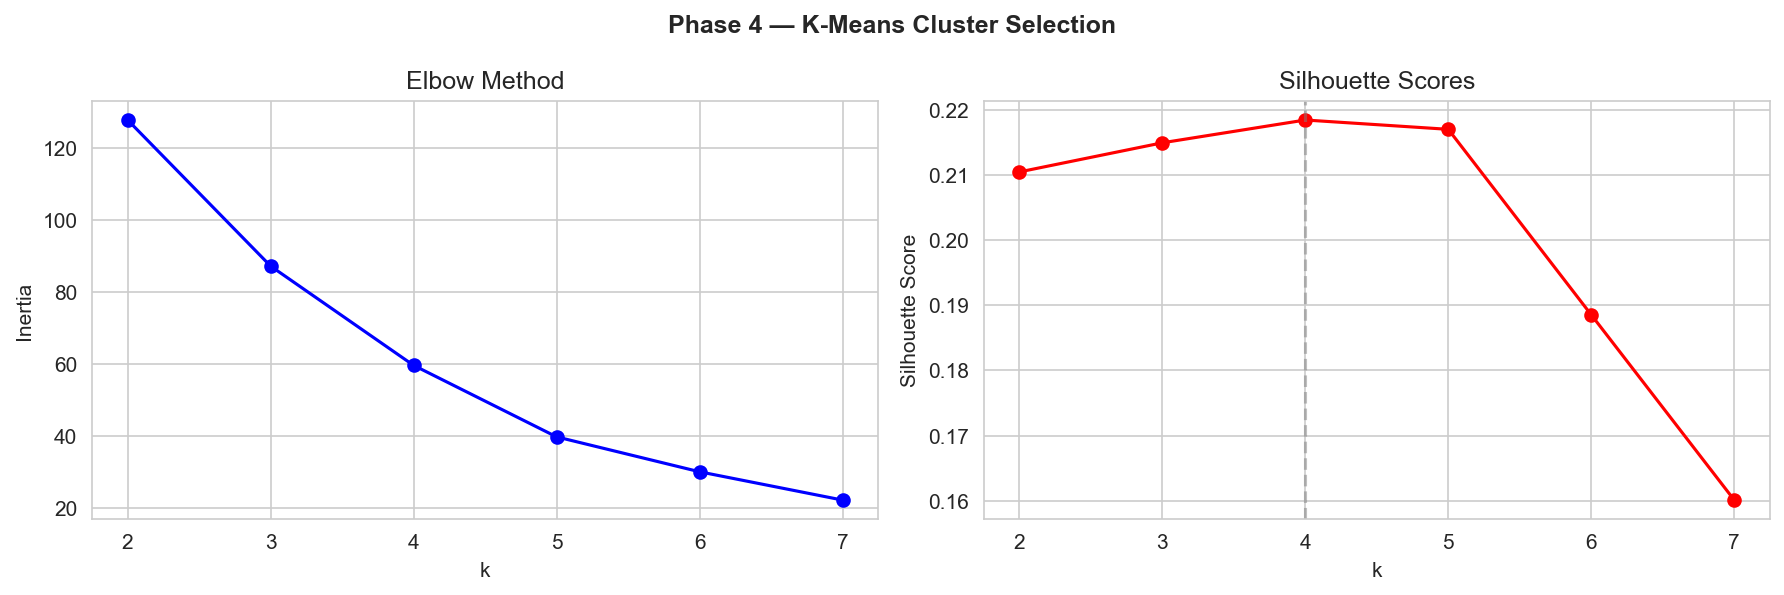


Cluster assignments:
  Cluster 0: ['berkley', 'eliotnorton', 'lyndenboro', 'tufts'] — PM2.5=9.9, WBGT=65.9
  Cluster 1: ['chin'] — PM2.5=10.5, WBGT=66.0
  Cluster 2: ['castle'] — PM2.5=8.2, WBGT=66.8
  Cluster 3: ['dewey', 'greenway', 'msh', 'oxford', 'reggie', 'taitung'] — PM2.5=9.2, WBGT=65.7


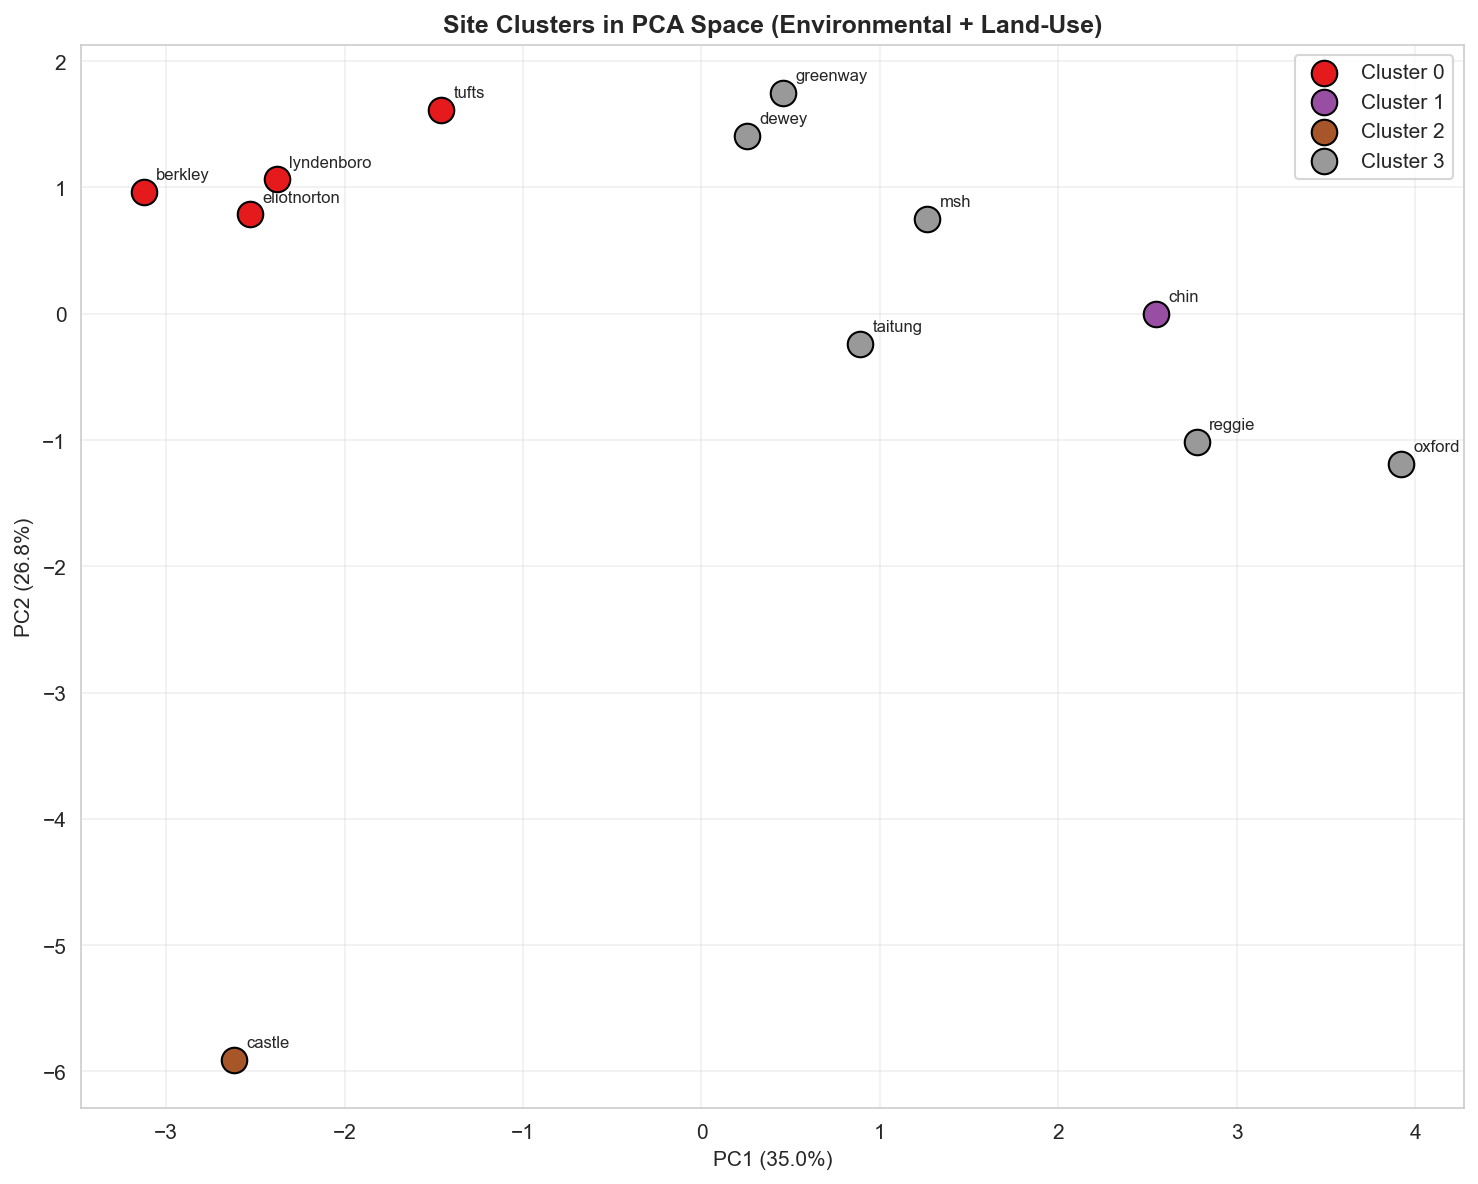

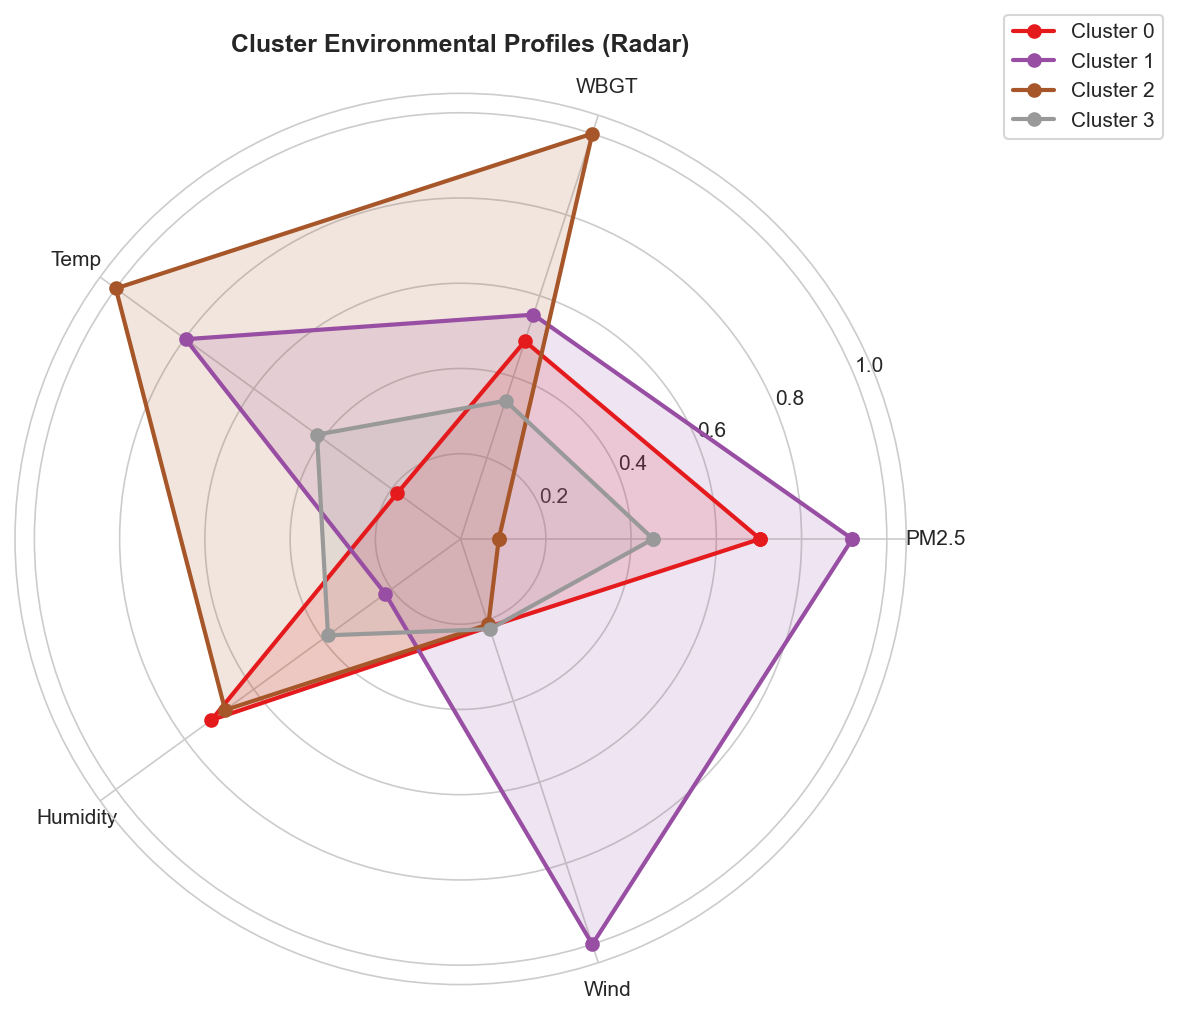

In [2]:
# Feature matrix: environmental + landuse
cluster_features = ['pm25_mean', 'wbgt_mean', 'temp_mean', 'humid_mean', 'wind_mean'] + LANDUSE_COLS
X_cluster = site_summary[cluster_features].dropna(axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Elbow + silhouette
K_range = range(2, 8)
inertias, sil_scores = [], []
for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

optimal_k = list(K_range)[np.argmax(sil_scores)]
print(f'Optimal k = {optimal_k} (silhouette = {max(sil_scores):.3f})')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(K_range), inertias, 'bo-')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia'); ax1.set_title('Elbow Method')
ax2.plot(list(K_range), sil_scores, 'ro-')
ax2.axvline(optimal_k, ls='--', color='gray', alpha=0.5)
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette Score'); ax2.set_title('Silhouette Scores')
plt.suptitle('Phase 4 — K-Means Cluster Selection', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'p4_kmeans_selection.png', bbox_inches='tight')
plt.show()

# Final clustering
km_final = KMeans(n_clusters=optimal_k, n_init=20, random_state=42)
site_summary['cluster'] = km_final.fit_predict(X_scaled)

print('\nCluster assignments:')
for c in range(optimal_k):
    sites = site_summary[site_summary.cluster == c].index.tolist()
    pm = site_summary.loc[sites, 'pm25_mean'].mean()
    wb = site_summary.loc[sites, 'wbgt_mean'].mean()
    print(f'  Cluster {c}: {sites} — PM2.5={pm:.1f}, WBGT={wb:.1f}')

# PCA biplot colored by cluster
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.Set1(np.linspace(0, 1, optimal_k))
for c in range(optimal_k):
    mask = site_summary.cluster.values == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[colors[c]], s=150,
              edgecolors='black', linewidth=1, label=f'Cluster {c}', zorder=5)
for i, sid in enumerate(site_summary.index):
    ax.annotate(sid, (X_pca[i, 0], X_pca[i, 1]), xytext=(6, 6),
               textcoords='offset points', fontsize=8)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('Site Clusters in PCA Space (Environmental + Land-Use)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'p4_kmeans_pca_biplot.png', bbox_inches='tight')
plt.show()

# Radar/spider chart per cluster
radar_vars = ['pm25_mean', 'wbgt_mean', 'temp_mean', 'humid_mean', 'wind_mean']
radar_labels = ['PM2.5', 'WBGT', 'Temp', 'Humidity', 'Wind']
angles = np.linspace(0, 2 * np.pi, len(radar_vars), endpoint=False).tolist()
angles += angles[:1]

# Normalize for radar (0-1 scale)
radar_data = site_summary[radar_vars].copy()
for col in radar_vars:
    radar_data[col] = (radar_data[col] - radar_data[col].min()) / (radar_data[col].max() - radar_data[col].min())

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for c in range(optimal_k):
    vals = radar_data[site_summary.cluster == c].mean().tolist()
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', color=colors[c], label=f'Cluster {c}', linewidth=2)
    ax.fill(angles, vals, alpha=0.15, color=colors[c])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels)
ax.set_title('Cluster Environmental Profiles (Radar)', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig(FIG_DIR / 'p4_kmeans_radar.png', bbox_inches='tight')
plt.show()

## 2. Regression Deep-Dive: Quantile Regression & Random Forest Feature Importance

Regression data: 46,253 obs

=== QUANTILE REGRESSION: PM2.5 ~ WBGT + Humidity + Wind + Hour ===
  Quantile    WBGT coef     WBGT p    Pseudo R²
      0.10       0.1824     0.0000       0.9078
      0.25       0.3302     0.0000       0.8836
      0.50       0.5743     0.0000       0.8430
      0.75       0.7465     0.0000       0.8797
      0.90       0.6258     0.0000       0.8857
      0.95       0.6489     0.0000       0.8587


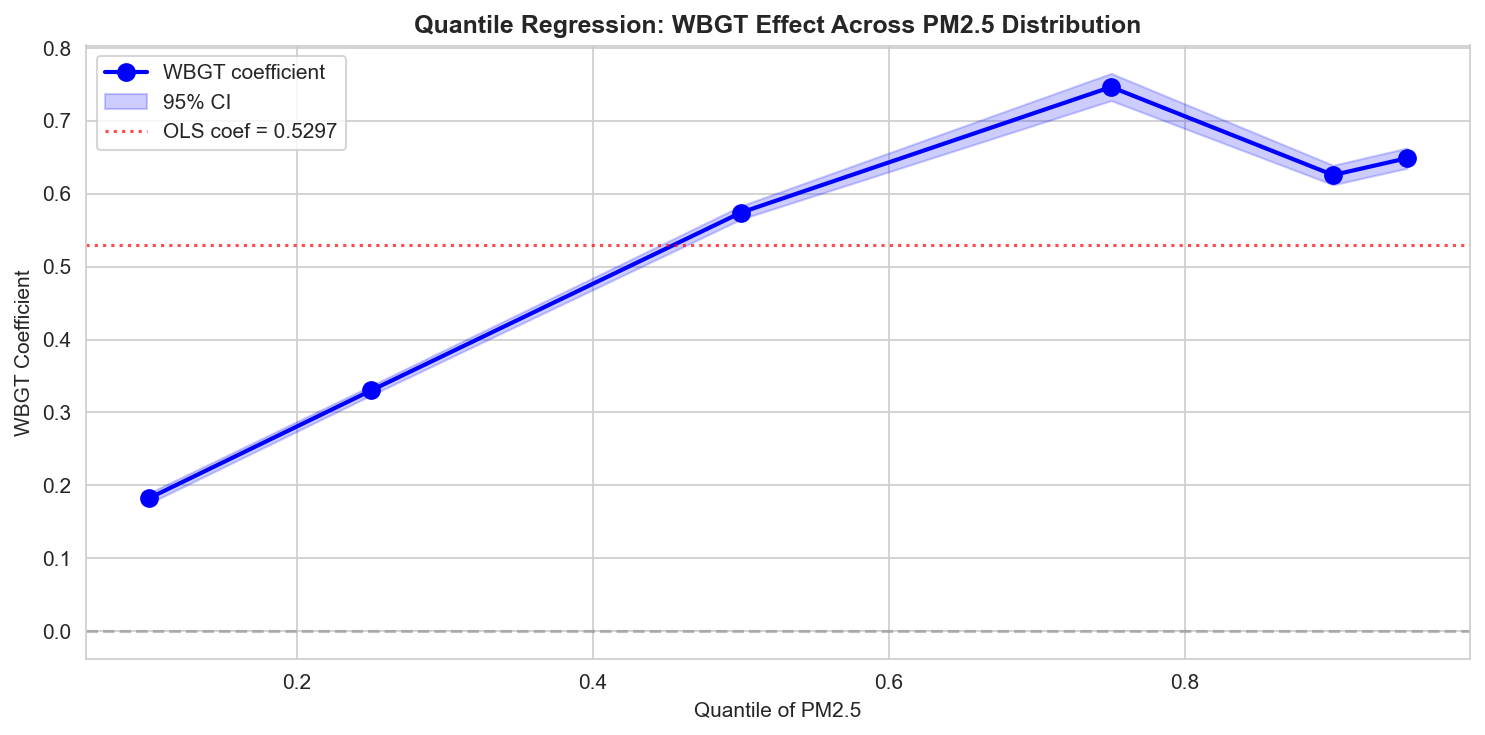


OLS R² = 0.2093
Key insight: WBGT effect on PM2.5 at 95th percentile vs median: 0.6489 vs 0.5743


In [3]:
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor

# Prepare observation-level regression data
reg_cols = [PM, WBGT, TEMP, HUMID, WIND, WDIR, 'hour', 'day_of_week']
reg_df = df[reg_cols + ['site_id']].dropna()
print(f'Regression data: {len(reg_df):,} obs')

# --- Quantile Regression (PM2.5 ~ WBGT + meteo) ---
predictors = [WBGT, HUMID, WIND, 'hour']
X_qr = sm.add_constant(reg_df[predictors])
y_qr = reg_df[PM]

quantiles = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
qr_results = {}
print('\n=== QUANTILE REGRESSION: PM2.5 ~ WBGT + Humidity + Wind + Hour ===')
print(f'{"Quantile":>10} {"WBGT coef":>12} {"WBGT p":>10} {"Pseudo R²":>12}')
for q in quantiles:
    mod = sm.QuantReg(y_qr, X_qr).fit(q=q, max_iter=5000)
    qr_results[q] = mod
    wbgt_coef = mod.params[WBGT]
    wbgt_p = mod.pvalues[WBGT]
    pseudo_r2 = 1 - mod.prsquared if hasattr(mod, 'prsquared') else np.nan
    print(f'{q:>10.2f} {wbgt_coef:>12.4f} {wbgt_p:>10.4f} {pseudo_r2:>12.4f}')

# Plot quantile regression coefficients for WBGT
fig, ax = plt.subplots(figsize=(10, 5))
coefs = [qr_results[q].params[WBGT] for q in quantiles]
ci_lo = [qr_results[q].conf_int().loc[WBGT, 0] for q in quantiles]
ci_hi = [qr_results[q].conf_int().loc[WBGT, 1] for q in quantiles]

ax.plot(quantiles, coefs, 'bo-', linewidth=2, markersize=8, label='WBGT coefficient')
ax.fill_between(quantiles, ci_lo, ci_hi, alpha=0.2, color='blue', label='95% CI')
ax.axhline(0, color='gray', ls='--', alpha=0.5)

# OLS reference
ols = sm.OLS(y_qr, X_qr).fit()
ax.axhline(ols.params[WBGT], color='red', ls=':', alpha=0.7, label=f'OLS coef = {ols.params[WBGT]:.4f}')

ax.set_xlabel('Quantile of PM2.5')
ax.set_ylabel('WBGT Coefficient')
ax.set_title('Quantile Regression: WBGT Effect Across PM2.5 Distribution', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'p4_quantile_regression.png', bbox_inches='tight')
plt.show()

print(f'\nOLS R² = {ols.rsquared:.4f}')
print(f'Key insight: WBGT effect on PM2.5 at 95th percentile vs median: '
      f'{qr_results[0.95].params[WBGT]:.4f} vs {qr_results[0.50].params[WBGT]:.4f}')


=== RANDOM FOREST FEATURE IMPORTANCE (R² = 0.740) ===
           Temperature: 0.2711
                  WBGT: 0.2128
           Day of Week: 0.2060
              Humidity: 0.1156
                  Hour: 0.1055
            Wind Speed: 0.0547
        Wind Direction: 0.0344


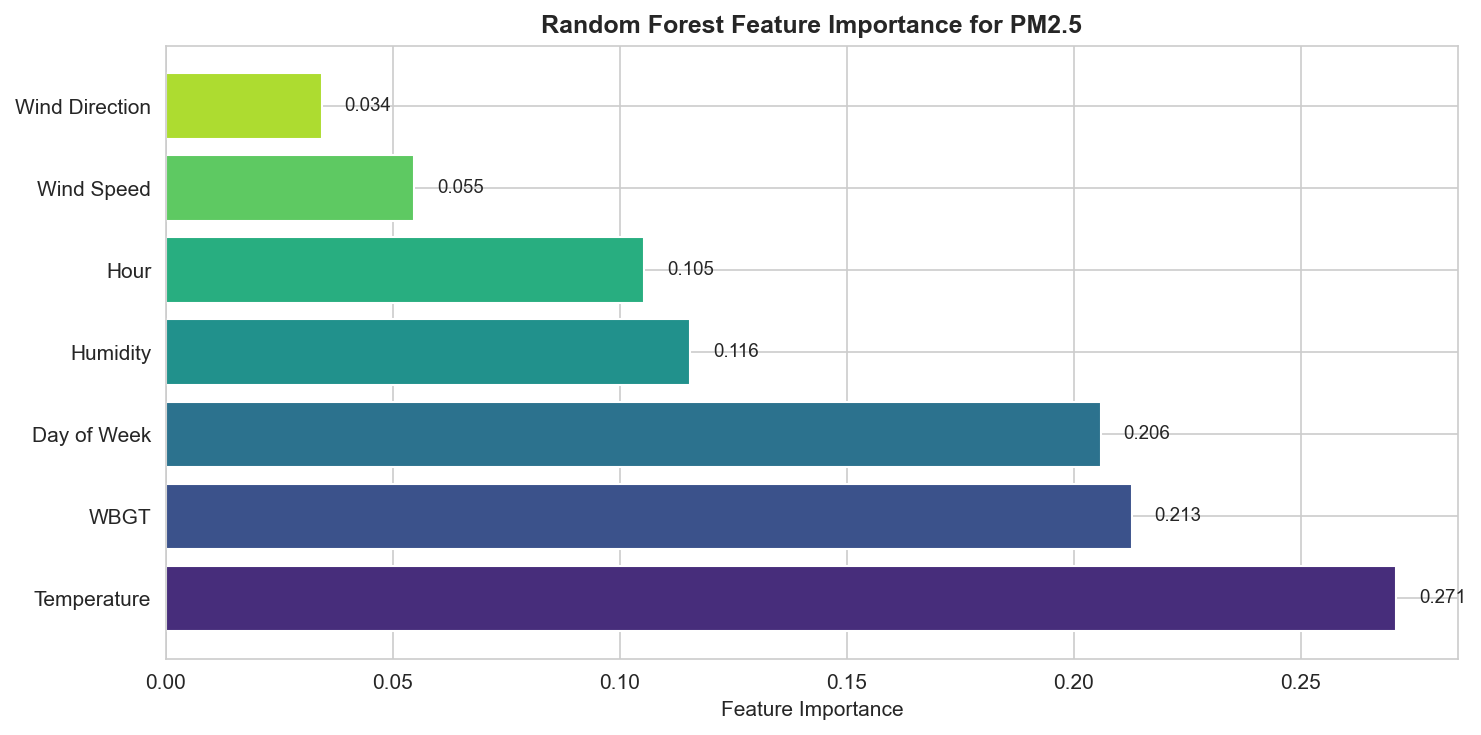

In [4]:
# --- Random Forest Feature Importance ---
rf_features = [WBGT, TEMP, HUMID, WIND, WDIR, 'hour', 'day_of_week']
X_rf = reg_df[rf_features].values
y_rf = reg_df[PM].values

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_rf, y_rf)
rf_r2 = rf.score(X_rf, y_rf)

importances = rf.feature_importances_
rf_labels = ['WBGT', 'Temperature', 'Humidity', 'Wind Speed', 'Wind Direction', 'Hour', 'Day of Week']
sorted_idx = np.argsort(importances)[::-1]

print(f'\n=== RANDOM FOREST FEATURE IMPORTANCE (R² = {rf_r2:.3f}) ===')
for i in sorted_idx:
    print(f'  {rf_labels[i]:>20}: {importances[i]:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh([rf_labels[i] for i in sorted_idx], [importances[i] for i in sorted_idx],
               color=sns.color_palette('viridis', len(rf_labels)))
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest Feature Importance for PM2.5', fontweight='bold')
for bar, val in zip(bars, [importances[i] for i in sorted_idx]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'p4_rf_importance.png', bbox_inches='tight')
plt.show()

## 3. Principal Component Analysis — Multi-Environmental Dimensionality Reduction

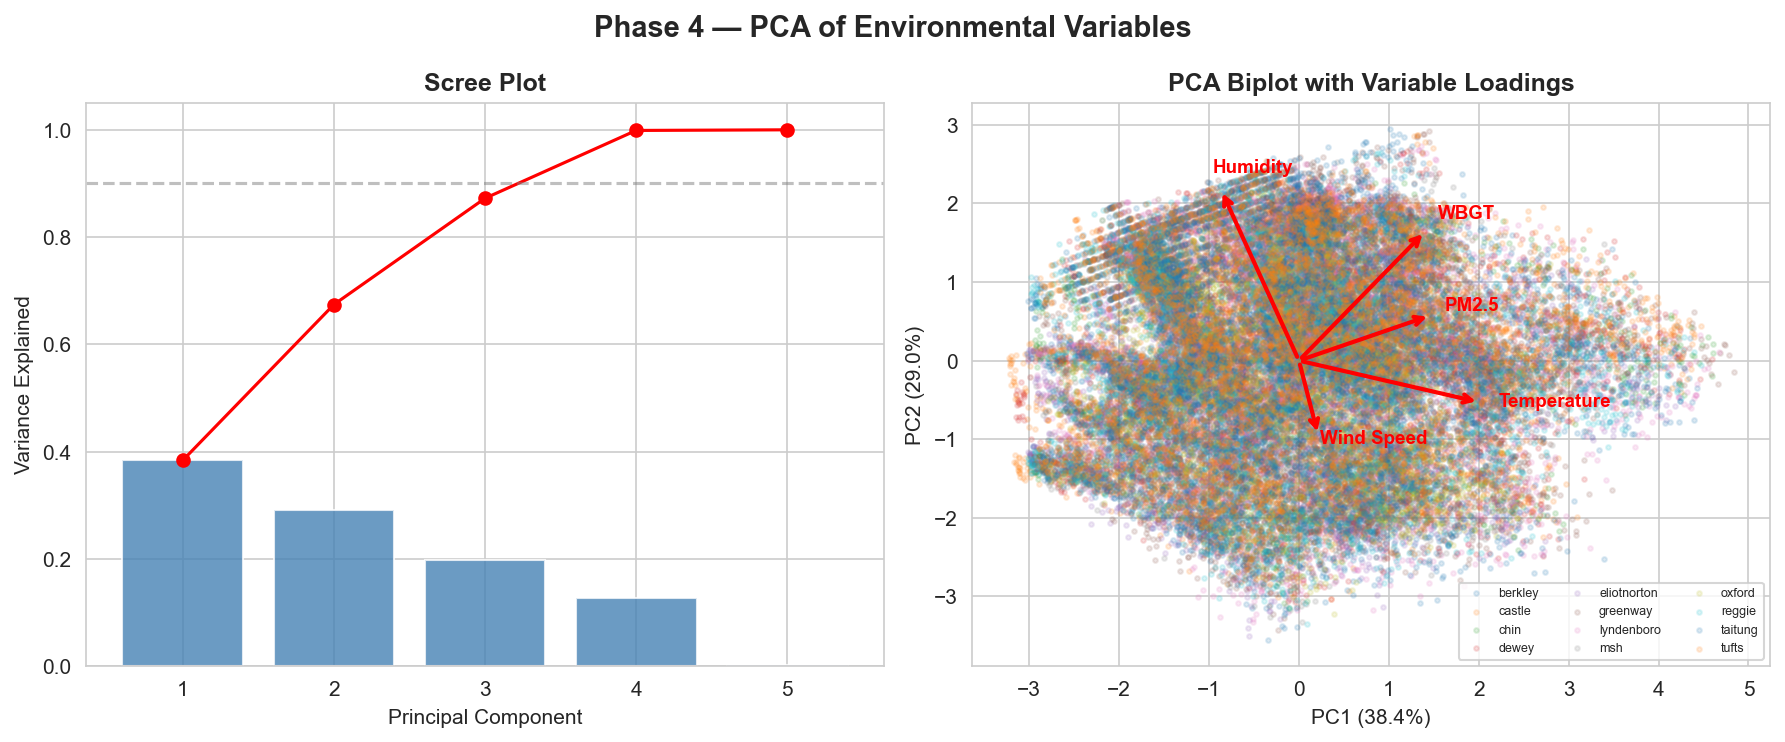

Loadings matrix:
     PM2.5   WBGT  Temperature  Humidity  Wind Speed
PC1  0.490  0.469        0.671    -0.289       0.072
PC2  0.192  0.549       -0.177     0.727      -0.319
PC3 -0.282  0.277        0.030     0.259       0.881
PC4  0.802 -0.311       -0.369     0.083       0.343
PC5  0.015 -0.552        0.617     0.561      -0.007

Cumulative variance: [0.384 0.674 0.872 0.999 1.   ]


In [5]:
# PCA on observation-level environmental data
pca_cols = [PM, WBGT, TEMP, HUMID, WIND]
pca_labels = ['PM2.5', 'WBGT', 'Temperature', 'Humidity', 'Wind Speed']
pca_df = df[pca_cols + ['site_id']].dropna()

scaler_pca = StandardScaler()
X_pca_full = scaler_pca.fit_transform(pca_df[pca_cols])

pca_full = PCA()
scores = pca_full.fit_transform(X_pca_full)

# Scree plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
n_comp = len(pca_cols)
ax1.bar(range(1, n_comp+1), pca_full.explained_variance_ratio_, color='steelblue', alpha=0.8)
ax1.plot(range(1, n_comp+1), np.cumsum(pca_full.explained_variance_ratio_), 'ro-')
ax1.axhline(0.9, ls='--', color='gray', alpha=0.5)
ax1.set_xlabel('Principal Component'); ax1.set_ylabel('Variance Explained')
ax1.set_title('Scree Plot', fontweight='bold')

# Biplot (PC1 vs PC2) with variable loadings
loadings = pca_full.components_[:2].T
scale_factor = 3

# Sample points for display (too many for all)
for sid in sorted(pca_df.site_id.unique()):
    mask = pca_df.site_id.values == sid
    ax2.scatter(scores[mask, 0], scores[mask, 1], s=5, alpha=0.15, label=sid)

for i, label in enumerate(pca_labels):
    ax2.annotate('', xy=(loadings[i, 0]*scale_factor, loadings[i, 1]*scale_factor),
                xytext=(0, 0), arrowprops=dict(arrowstyle='->', color='red', lw=2))
    ax2.text(loadings[i, 0]*scale_factor*1.1, loadings[i, 1]*scale_factor*1.1,
            label, color='red', fontweight='bold', fontsize=9)

ax2.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]:.1%})')
ax2.set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]:.1%})')
ax2.set_title('PCA Biplot with Variable Loadings', fontweight='bold')
ax2.legend(fontsize=6, ncol=3, loc='lower right')

plt.suptitle('Phase 4 — PCA of Environmental Variables', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / 'p4_pca_biplot.png', bbox_inches='tight')
plt.show()

print('Loadings matrix:')
loadings_df = pd.DataFrame(pca_full.components_, columns=pca_labels,
                           index=[f'PC{i+1}' for i in range(n_comp)])
print(loadings_df.round(3).to_string())
print(f'\nCumulative variance: {np.cumsum(pca_full.explained_variance_ratio_).round(3)}')

## 4. Spatial Analysis — Interactive Folium Maps

folium not available — generating static map only


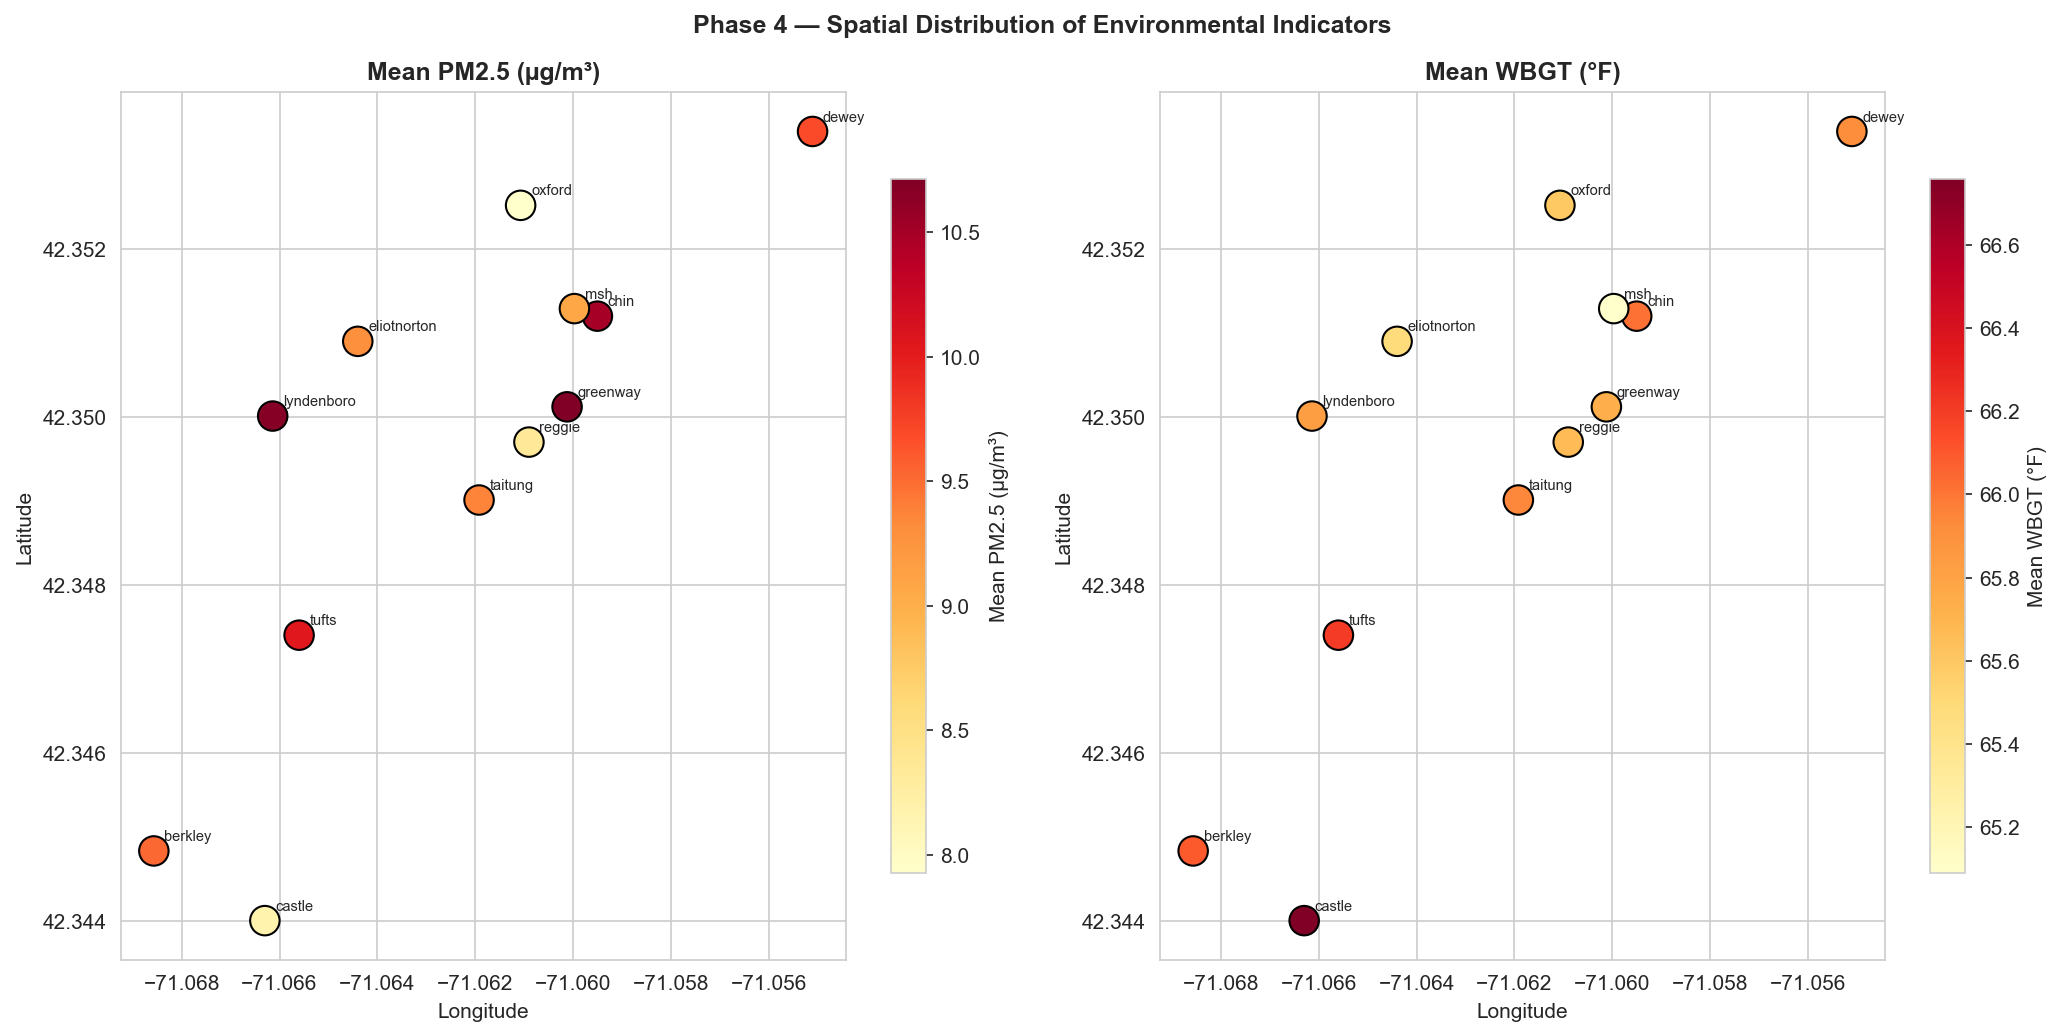

Skipped interactive map (folium not installed)


In [6]:
try:
    import folium
    from folium.plugins import MarkerCluster
    HAS_FOLIUM = True
except ImportError:
    HAS_FOLIUM = False
    print('folium not available — generating static map only')

# Static matplotlib map
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for idx, (metric, label, cmap) in enumerate([
    ('pm25_mean', 'Mean PM2.5 (µg/m³)', 'YlOrRd'),
    ('wbgt_mean', 'Mean WBGT (°F)', 'YlOrRd')
]):
    ax = axes[idx]
    sc = ax.scatter(site_summary.lon, site_summary.lat,
                   c=site_summary[metric], cmap=cmap,
                   s=200, edgecolors='black', linewidth=1, zorder=5)
    for sid in site_summary.index:
        ax.annotate(sid, (site_summary.loc[sid, 'lon'], site_summary.loc[sid, 'lat']),
                   xytext=(5, 5), textcoords='offset points', fontsize=7)
    plt.colorbar(sc, ax=ax, label=label, shrink=0.8)
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.set_title(label, fontweight='bold')

plt.suptitle('Phase 4 — Spatial Distribution of Environmental Indicators', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'p4_spatial_static.png', bbox_inches='tight')
plt.show()

# Interactive Folium map
if HAS_FOLIUM:
    center_lat = site_summary.lat.mean()
    center_lon = site_summary.lon.mean()
    m = folium.Map(location=[center_lat, center_lon], zoom_start=16, tiles='CartoDB positron')

    # Color scale for PM2.5
    pm_min, pm_max = site_summary.pm25_mean.min(), site_summary.pm25_mean.max()
    
    for sid, row in site_summary.iterrows():
        # Color: green to red based on PM2.5
        ratio = (row.pm25_mean - pm_min) / (pm_max - pm_min) if pm_max > pm_min else 0.5
        r = int(255 * ratio)
        g = int(255 * (1 - ratio))
        color = f'#{r:02x}{g:02x}00'
        
        popup_html = f"""
        <b>{sid}</b><br>
        PM2.5: {row.pm25_mean:.1f} µg/m³<br>
        WBGT: {row.wbgt_mean:.1f} °F<br>
        Temp: {row.temp_mean:.1f} °F<br>
        Cluster: {int(row.cluster)}<br>
        N obs: {int(row.n_obs):,}
        """
        
        folium.CircleMarker(
            location=[row.lat, row.lon],
            radius=12,
            color='black',
            weight=1,
            fill=True,
            fill_color=color,
            fill_opacity=0.8,
            popup=folium.Popup(popup_html, max_width=200),
            tooltip=f"{sid}: PM2.5={row.pm25_mean:.1f}"
        ).add_to(m)

    map_path = FIG_DIR / 'p4_interactive_map.html'
    m.save(str(map_path))
    print(f'Interactive map saved to: {map_path}')
else:
    print('Skipped interactive map (folium not installed)')

## 5. Change-Point Detection — Identifying Regime Shifts

PM2.5 change point: 2023-08-18 (K=155, p=0.0990)
WBGT  change point: 2023-08-23 (K=106, p=0.4903)


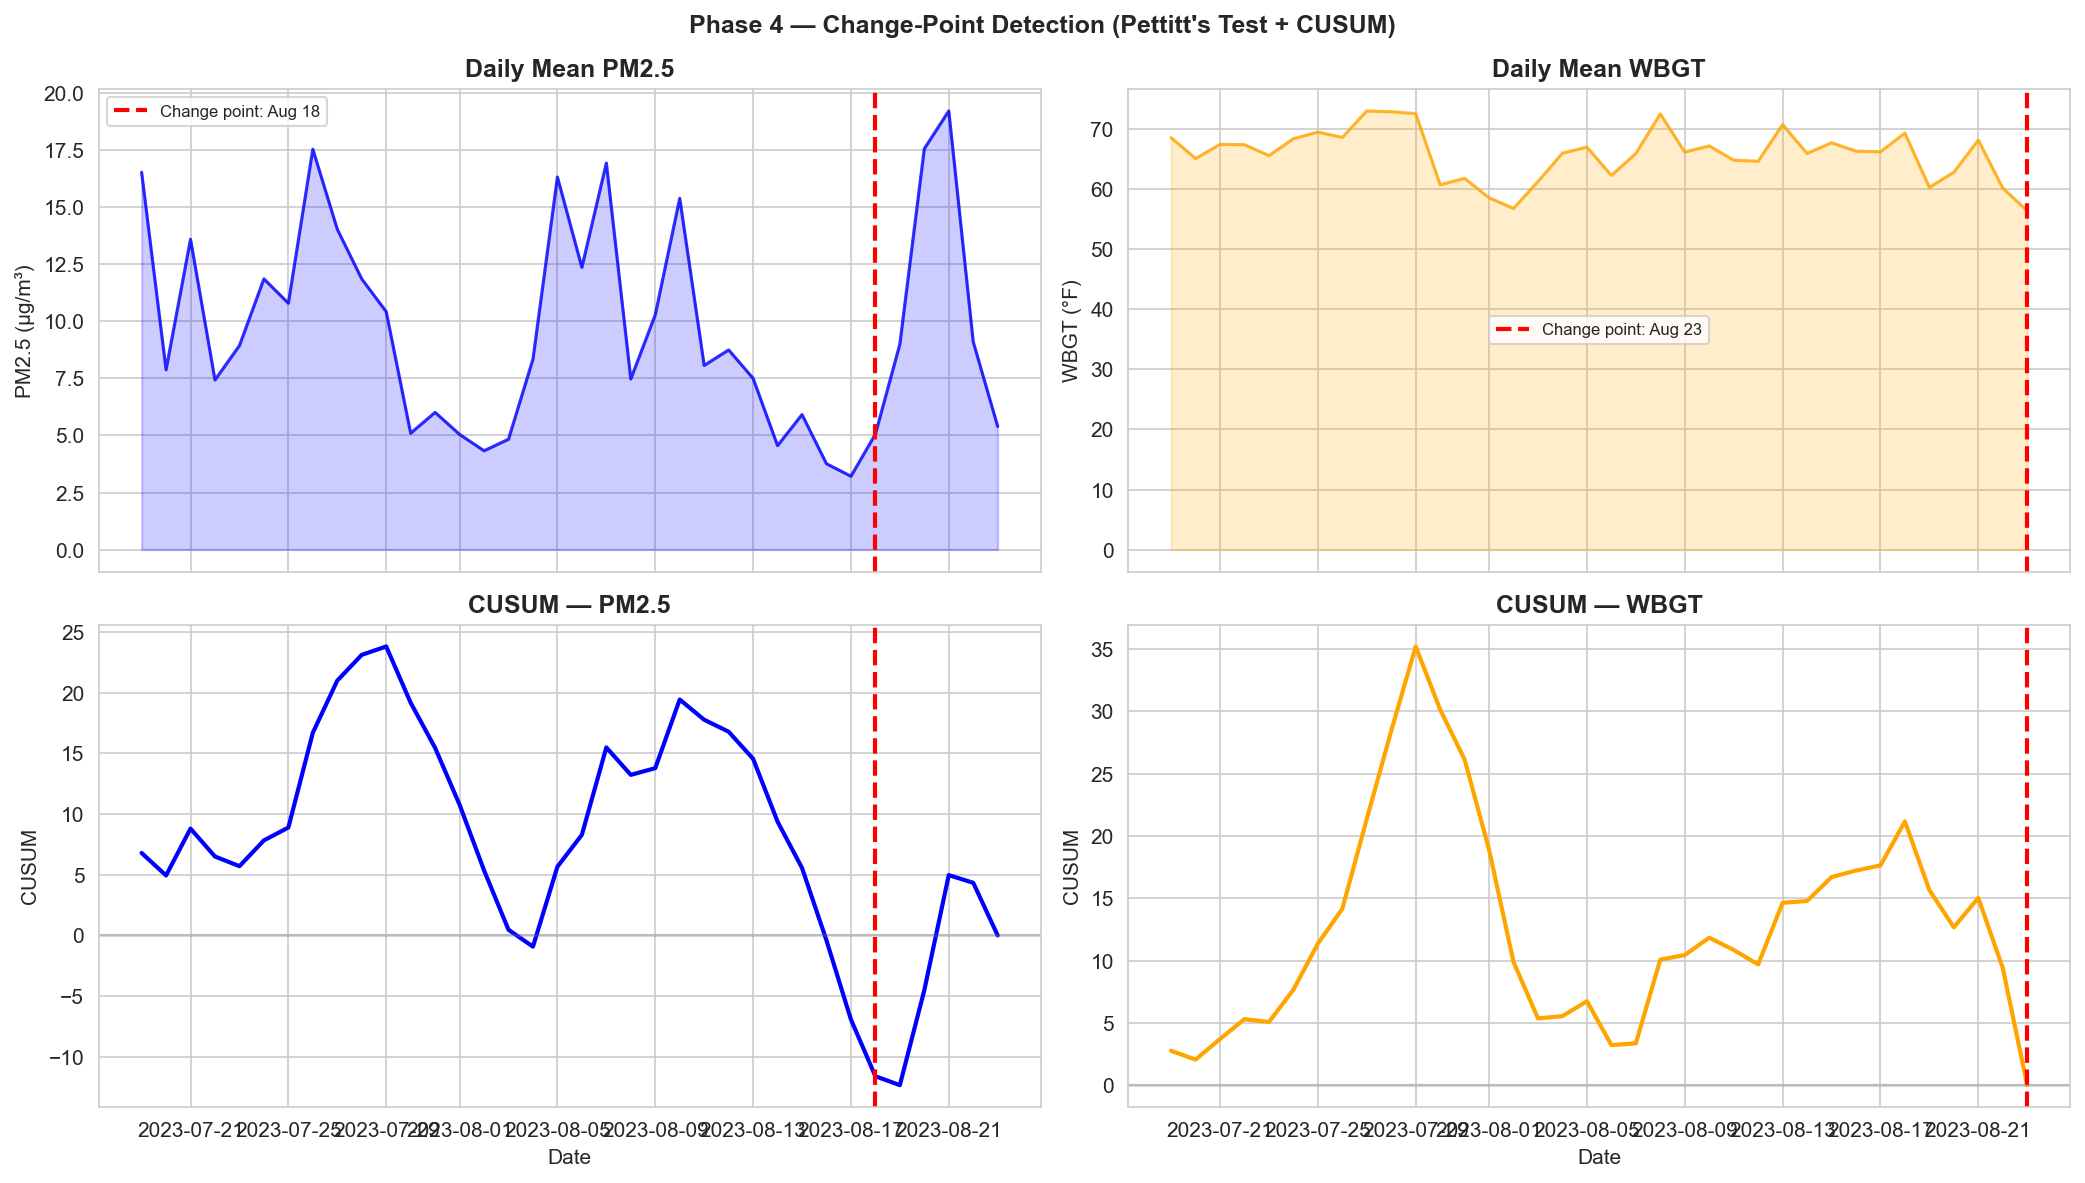


PM2.5 pre vs post change-point: 9.4 vs 12.1 µg/m³ (t-test p=0.2270)


In [7]:
# Daily aggregates
daily = df.groupby('date_only').agg(
    pm25_mean=(PM, 'mean'),
    pm25_max=(PM, 'max'),
    wbgt_mean=(WBGT, 'mean'),
    wbgt_max=(WBGT, 'max')
).reset_index()
daily['date'] = pd.to_datetime(daily['date_only'])
daily = daily.sort_values('date').reset_index(drop=True)

# CUSUM for PM2.5
def cusum(series):
    """Compute CUSUM statistic for change-point detection."""
    mean_val = series.mean()
    cumsum = np.cumsum(series - mean_val)
    return cumsum

cusum_pm25 = cusum(daily.pm25_mean.values)
cusum_wbgt = cusum(daily.wbgt_mean.values)

# Pettitt's test implementation
def pettitt_test(data):
    """Pettitt's test for a single change point."""
    n = len(data)
    U = np.zeros(n)
    for t in range(n):
        for j in range(n):
            U[t] += np.sign(data[t] - data[j])
    U = np.cumsum(np.array([np.sum(np.sign(data[t] - data[:t])) for t in range(n)]))
    # Use rank-based version
    ranks = stats.rankdata(data)
    U_t = np.zeros(n)
    for t in range(1, n):
        U_t[t] = U_t[t-1] + np.sum(np.sign(data[t] - data[:t]))
    K = np.max(np.abs(U_t))
    tau = np.argmax(np.abs(U_t))
    # Approximate p-value
    p_val = 2 * np.exp(-6 * K**2 / (n**3 + n**2))
    return tau, K, min(p_val, 1.0)

tau_pm, K_pm, p_pm = pettitt_test(daily.pm25_mean.values)
tau_wb, K_wb, p_wb = pettitt_test(daily.wbgt_mean.values)

cp_date_pm = daily.date.iloc[tau_pm]
cp_date_wb = daily.date.iloc[tau_wb]

print(f'PM2.5 change point: {cp_date_pm.strftime("%Y-%m-%d")} (K={K_pm:.0f}, p={p_pm:.4f})')
print(f'WBGT  change point: {cp_date_wb.strftime("%Y-%m-%d")} (K={K_wb:.0f}, p={p_wb:.4f})')

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex='col')

# PM2.5 time series + change point
ax = axes[0, 0]
ax.plot(daily.date, daily.pm25_mean, 'b-', alpha=0.8)
ax.fill_between(daily.date, daily.pm25_mean, alpha=0.2, color='blue')
ax.axvline(cp_date_pm, color='red', ls='--', lw=2, label=f'Change point: {cp_date_pm.strftime("%b %d")}')
ax.set_ylabel('PM2.5 (µg/m³)'); ax.set_title('Daily Mean PM2.5', fontweight='bold')
ax.legend(fontsize=8)

# PM2.5 CUSUM
ax = axes[1, 0]
ax.plot(daily.date, cusum_pm25, 'b-', linewidth=2)
ax.axvline(cp_date_pm, color='red', ls='--', lw=2)
ax.axhline(0, color='gray', ls='-', alpha=0.3)
ax.set_ylabel('CUSUM'); ax.set_title('CUSUM — PM2.5', fontweight='bold')
ax.set_xlabel('Date')

# WBGT time series + change point
ax = axes[0, 1]
ax.plot(daily.date, daily.wbgt_mean, color='orange', alpha=0.8)
ax.fill_between(daily.date, daily.wbgt_mean, alpha=0.2, color='orange')
ax.axvline(cp_date_wb, color='red', ls='--', lw=2, label=f'Change point: {cp_date_wb.strftime("%b %d")}')
ax.set_ylabel('WBGT (°F)'); ax.set_title('Daily Mean WBGT', fontweight='bold')
ax.legend(fontsize=8)

# WBGT CUSUM
ax = axes[1, 1]
ax.plot(daily.date, cusum_wbgt, color='orange', linewidth=2)
ax.axvline(cp_date_wb, color='red', ls='--', lw=2)
ax.axhline(0, color='gray', ls='-', alpha=0.3)
ax.set_ylabel('CUSUM'); ax.set_title('CUSUM — WBGT', fontweight='bold')
ax.set_xlabel('Date')

plt.suptitle('Phase 4 — Change-Point Detection (Pettitt\'s Test + CUSUM)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'p4_changepoint.png', bbox_inches='tight')
plt.show()

# Pre/post change-point comparison
pre = daily[daily.date <= cp_date_pm].pm25_mean
post = daily[daily.date > cp_date_pm].pm25_mean
t_stat, t_pval = stats.ttest_ind(pre, post)
print(f'\nPM2.5 pre vs post change-point: {pre.mean():.1f} vs {post.mean():.1f} µg/m³ (t-test p={t_pval:.4f})')

## 6. Anomaly Detection

Total anomalies detected: 926 (2.0%)

Anomalies by site:
  lyndenboro: 134
  castle: 128
  greenway: 116
  taitung: 102
  dewey: 98
  chin: 79
  reggie: 74
  eliotnorton: 62
  tufts: 60
  berkley: 55
  msh: 17
  oxford: 1

PM2.5 z-score > 3: 0 readings

WBGT z-score > 3: 0 readings


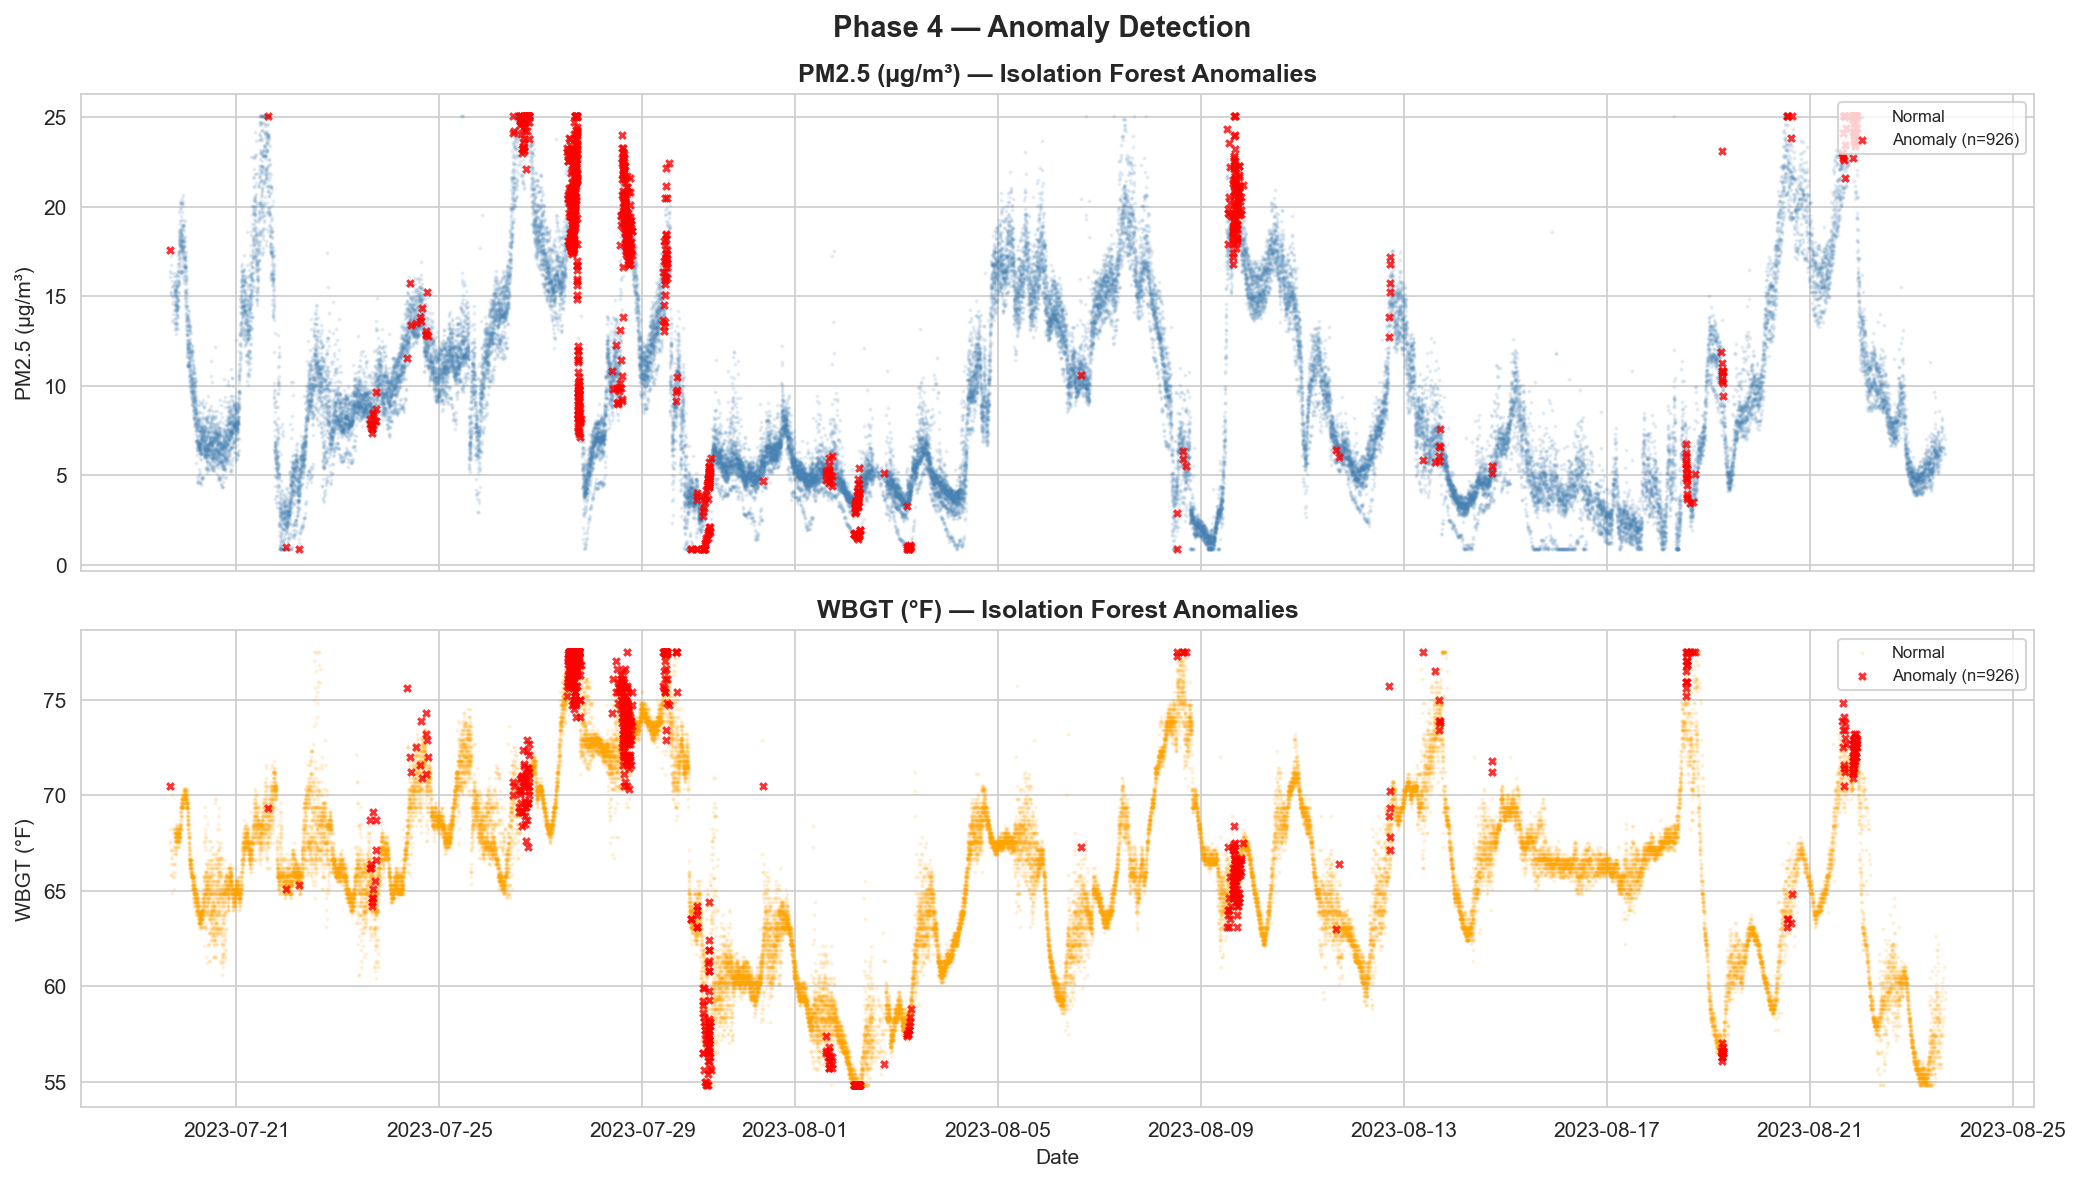


Top 10 most anomalous readings (lowest decision score):
           datetime    site_id  pa_mean_pm2_5_atm_b_corr_2  kes_mean_wbgt_f  anomaly_score
2023-07-27 15:10:00   greenway                   23.151201             77.4      -0.128905
2023-07-27 16:10:00   greenway                   25.086852             77.5      -0.117463
2023-07-27 16:10:00       chin                   22.649255             77.5      -0.114087
2023-07-27 15:10:00 lyndenboro                   20.200831             77.5      -0.110051
2023-07-27 16:40:00   greenway                   25.086852             77.5      -0.103815
2023-07-27 16:10:00      dewey                   21.825556             77.2      -0.103110
2023-07-27 15:10:00     reggie                   18.566872             77.4      -0.103089
2023-07-27 15:20:00   greenway                   22.393116             77.5      -0.102605
2023-07-27 15:10:00      tufts                   19.970430             77.5      -0.100723
2023-07-27 16:30:00   greenway   

In [8]:
# Isolation Forest on PM2.5 + WBGT + meteorological data
anom_cols = [PM, WBGT, TEMP, HUMID, WIND]
anom_df = df[anom_cols + ['site_id', 'datetime']].dropna().copy()

iso_forest = IsolationForest(contamination=0.02, random_state=42, n_jobs=-1)
anom_df['anomaly'] = iso_forest.fit_predict(anom_df[anom_cols])
anom_df['anomaly_score'] = iso_forest.decision_function(anom_df[anom_cols])

n_anomalies = (anom_df.anomaly == -1).sum()
print(f'Total anomalies detected: {n_anomalies:,} ({n_anomalies/len(anom_df)*100:.1f}%)')
print(f'\nAnomalies by site:')
anom_by_site = anom_df[anom_df.anomaly == -1].groupby('site_id').size().sort_values(ascending=False)
for sid, count in anom_by_site.items():
    print(f'  {sid}: {count}')

# Also z-score-based anomalies (for comparison)
z_threshold = 3
for col in [PM, WBGT]:
    z_scores = np.abs(stats.zscore(df[col].dropna()))
    n_zscore = (z_scores > z_threshold).sum()
    col_short = 'PM2.5' if 'pm' in col else 'WBGT'
    print(f'\n{col_short} z-score > {z_threshold}: {n_zscore} readings')

# Visualize anomalies
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

normal = anom_df[anom_df.anomaly == 1]
anomalous = anom_df[anom_df.anomaly == -1]

for idx, (col, label, color) in enumerate([
    (PM, 'PM2.5 (µg/m³)', 'steelblue'),
    (WBGT, 'WBGT (°F)', 'orange')
]):
    ax = axes[idx]
    ax.scatter(normal.datetime, normal[col], s=1, alpha=0.1, color=color, label='Normal')
    ax.scatter(anomalous.datetime, anomalous[col], s=10, alpha=0.8, color='red',
              marker='x', label=f'Anomaly (n={len(anomalous)})', zorder=5)
    ax.set_ylabel(label)
    ax.legend(loc='upper right', fontsize=8)
    ax.set_title(f'{label} — Isolation Forest Anomalies', fontweight='bold')

axes[-1].set_xlabel('Date')
plt.suptitle('Phase 4 — Anomaly Detection', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / 'p4_anomaly_detection.png', bbox_inches='tight')
plt.show()

# Top anomalies
print('\nTop 10 most anomalous readings (lowest decision score):')
top_anom = anom_df.nsmallest(10, 'anomaly_score')
print(top_anom[['datetime', 'site_id', PM, WBGT, 'anomaly_score']].to_string(index=False))

## 7. Sankey Rank Diagrams — PM2.5 vs WBGT Site Rankings

Site Rankings: PM2.5 vs WBGT
       Site  PM25_Rank  WBGT_Rank  PM25_Mean  WBGT_Mean  Rank_Diff
   greenway          1          8     10.715     65.732         -7
 lyndenboro          2          7     10.678     65.829         -5
       chin          3          4     10.489     66.013         -1
      tufts          4          2     10.044     66.209          2
      dewey          5          6      9.695     65.919         -1
    berkley          6          3      9.526     66.095          3
    taitung          7          5      9.365     65.941          2
eliotnorton          8         11      9.293     65.483         -3
        msh          9         12      9.073     65.090         -3
     reggie         10          9      8.341     65.666          1
     castle         11          1      8.175     66.758         10
     oxford         12         10      7.925     65.604          2


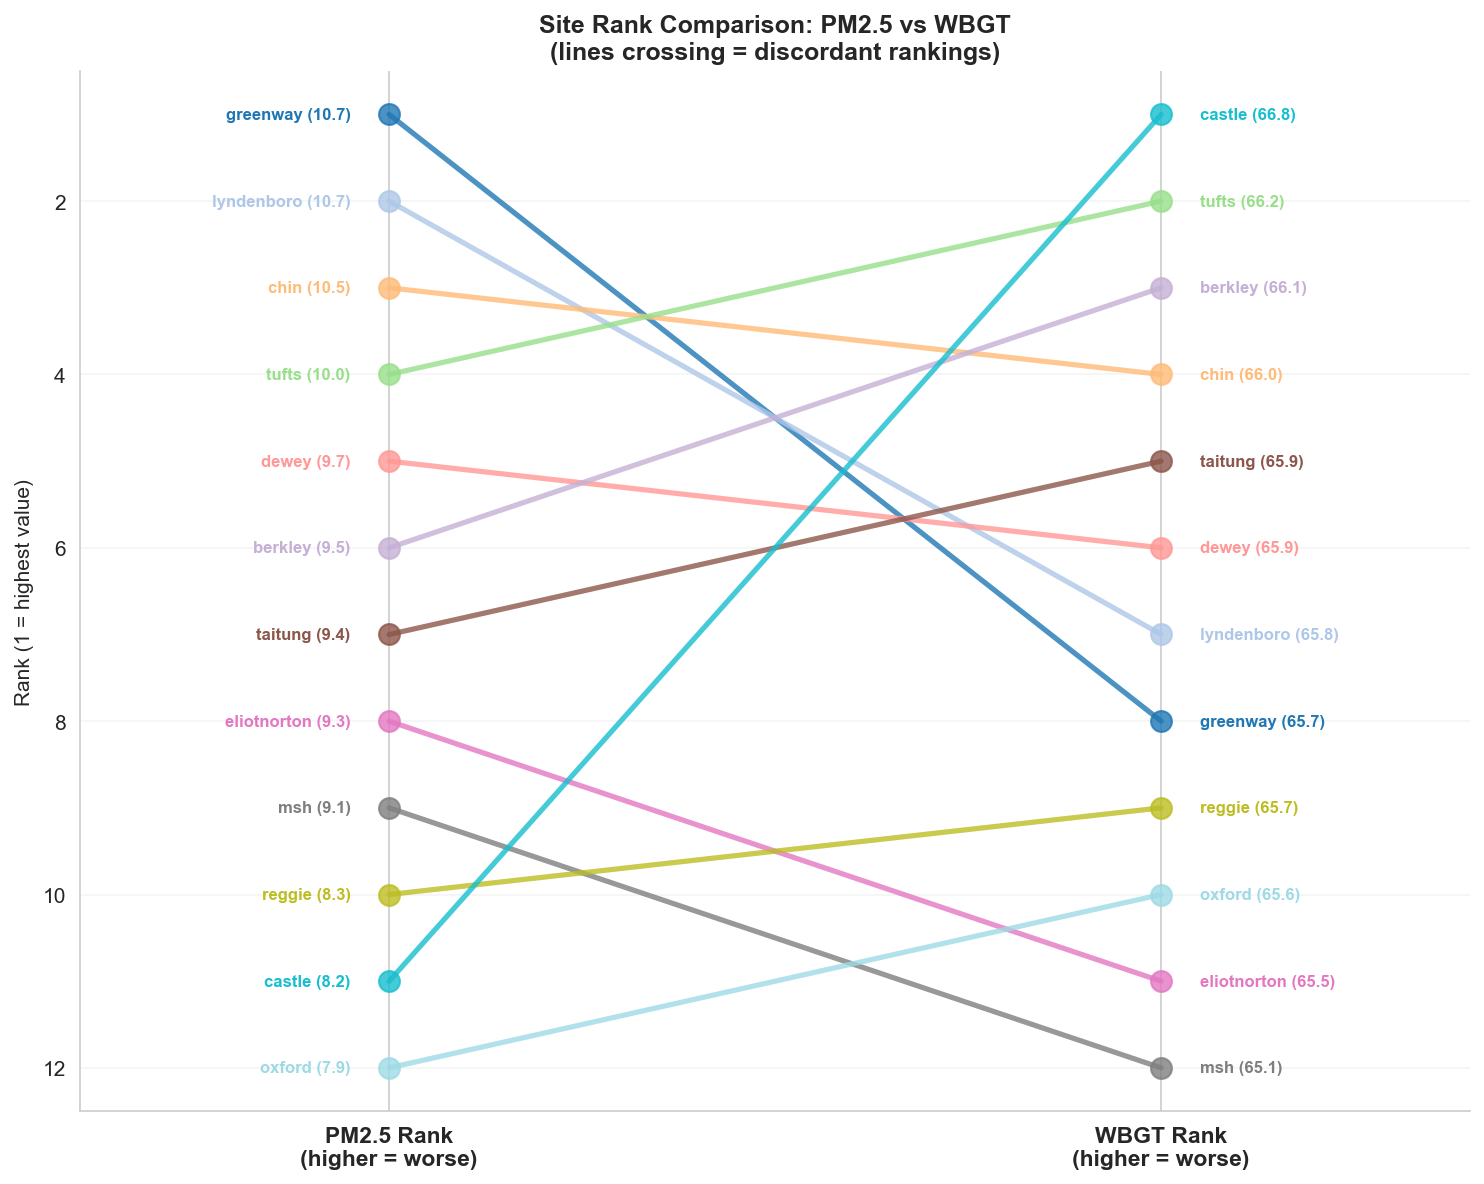


Spearman rank correlation (PM2.5 vs WBGT): ρ = 0.245, p = 0.4433

Largest rank discordances (PM2.5 rank − WBGT rank):
  castle: diff = +10 (worse for WBGT)
  greenway: diff = -7 (worse for PM2.5)
  lyndenboro: diff = -5 (worse for PM2.5)
  berkley: diff = +3 (worse for WBGT)
  eliotnorton: diff = -3 (worse for PM2.5)


In [9]:
# Rank sites by PM2.5 and WBGT
pm25_rank = site_summary.pm25_mean.rank(ascending=False).astype(int)
wbgt_rank = site_summary.wbgt_mean.rank(ascending=False).astype(int)

rank_df = pd.DataFrame({
    'Site': site_summary.index,
    'PM25_Rank': pm25_rank.values,
    'WBGT_Rank': wbgt_rank.values,
    'PM25_Mean': site_summary.pm25_mean.values,
    'WBGT_Mean': site_summary.wbgt_mean.values
}).sort_values('PM25_Rank')

rank_df['Rank_Diff'] = rank_df.PM25_Rank - rank_df.WBGT_Rank

print('Site Rankings: PM2.5 vs WBGT')
print(rank_df.to_string(index=False))

# Bump chart / slope chart (Sankey-inspired)
fig, ax = plt.subplots(figsize=(10, 8))

n_sites = len(rank_df)
cmap = plt.cm.tab20(np.linspace(0, 1, n_sites))

for i, (_, row) in enumerate(rank_df.iterrows()):
    color = cmap[i]
    # Draw lines connecting PM2.5 rank (left) to WBGT rank (right)
    ax.plot([0, 1], [row.PM25_Rank, row.WBGT_Rank], '-o', color=color,
           linewidth=2.5, markersize=10, alpha=0.8)
    # Labels
    ax.text(-0.05, row.PM25_Rank, f"{row.Site} ({row.PM25_Mean:.1f})",
           ha='right', va='center', fontsize=8, color=color, fontweight='bold')
    ax.text(1.05, row.WBGT_Rank, f"{row.Site} ({row.WBGT_Mean:.1f})",
           ha='left', va='center', fontsize=8, color=color, fontweight='bold')

ax.set_xlim(-0.4, 1.4)
ax.set_ylim(n_sites + 0.5, 0.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(['PM2.5 Rank\n(higher = worse)', 'WBGT Rank\n(higher = worse)'],
                   fontweight='bold', fontsize=11)
ax.set_ylabel('Rank (1 = highest value)')
ax.set_title('Site Rank Comparison: PM2.5 vs WBGT\n(lines crossing = discordant rankings)',
            fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.2, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / 'p4_sankey_rank.png', bbox_inches='tight')
plt.show()

# Rank correlation
rho, p_rho = stats.spearmanr(pm25_rank, wbgt_rank)
print(f'\nSpearman rank correlation (PM2.5 vs WBGT): ρ = {rho:.3f}, p = {p_rho:.4f}')

# Sites with largest rank discordance
print('\nLargest rank discordances (PM2.5 rank − WBGT rank):')
for _, row in rank_df.sort_values('Rank_Diff', key=abs, ascending=False).head(5).iterrows():
    direction = 'worse for PM2.5' if row.Rank_Diff < 0 else 'worse for WBGT'
    print(f'  {row.Site}: diff = {row.Rank_Diff:+d} ({direction})')

## 8. Environmental Justice Framing — EPA NAAQS & OSHA Thresholds

In [10]:
# EPA NAAQS thresholds for PM2.5
NAAQS_24HR = 35.0  # µg/m³ (24-hour standard)
NAAQS_ANNUAL = 9.0  # µg/m³ (annual standard, revised 2024)
EPA_AQI_MODERATE = 12.0  # Above this = AQI > 50 (moderate)

# OSHA heat stress action levels (WBGT in °F)
OSHA_CAUTION = 80.0  # °F
OSHA_WARNING = 85.0  # °F
OSHA_DANGER = 88.0   # °F

# Study-period averages vs thresholds
print('=== ENVIRONMENTAL JUSTICE THRESHOLD ANALYSIS ===')
print(f'\nPM2.5 THRESHOLDS:')
print(f'  EPA NAAQS Annual Standard: {NAAQS_ANNUAL} µg/m³')
print(f'  EPA NAAQS 24-Hour Standard: {NAAQS_24HR} µg/m³')
print(f'  AQI "Moderate" threshold: {EPA_AQI_MODERATE} µg/m³')

# Calculate exceedance metrics
# Study-period mean by site vs annual NAAQS
exceed_annual = site_summary[site_summary.pm25_mean > NAAQS_ANNUAL].index.tolist()
print(f'\n  Sites exceeding annual NAAQS ({NAAQS_ANNUAL} µg/m³) during study:')
for sid in site_summary.sort_values('pm25_mean', ascending=False).index:
    flag = ' ⚠️ EXCEEDS' if sid in exceed_annual else ''
    print(f'    {sid}: {site_summary.loc[sid, "pm25_mean"]:.1f} µg/m³{flag}')

# Hourly readings above moderate AQI
pm_valid = df[PM].dropna()
pct_moderate = (pm_valid > EPA_AQI_MODERATE).mean() * 100
pct_24hr = False  # Need daily averages
print(f'\n  Readings > {EPA_AQI_MODERATE} µg/m³ (moderate AQI): {pct_moderate:.1f}%')

# Daily mean exceedance of 24-hr NAAQS
daily_pm = df.groupby(['date_only', 'site_id'])[PM].mean()
n_daily = len(daily_pm)
n_exceed_24 = (daily_pm > NAAQS_24HR).sum()
print(f'  Site-days > {NAAQS_24HR} µg/m³ (24-hr NAAQS): {n_exceed_24} / {n_daily} ({n_exceed_24/n_daily*100:.2f}%)')

print(f'\nWBGT / HEAT STRESS THRESHOLDS:')
print(f'  OSHA Caution: {OSHA_CAUTION} °F WBGT')
print(f'  OSHA Warning: {OSHA_WARNING} °F WBGT')
print(f'  OSHA Danger:  {OSHA_DANGER} °F WBGT')

wb_valid = df[WBGT].dropna()
pct_caution = (wb_valid > OSHA_CAUTION).mean() * 100
pct_warning = (wb_valid > OSHA_WARNING).mean() * 100
max_wbgt = wb_valid.max()
print(f'\n  Max WBGT recorded: {max_wbgt:.1f} °F')
print(f'  Readings > OSHA Caution ({OSHA_CAUTION} °F): {pct_caution:.2f}%')
print(f'  Readings > OSHA Warning ({OSHA_WARNING} °F): {pct_warning:.2f}%')
print(f'  → No readings exceeded OSHA action levels during study period')

# Compound exposure: high PM2.5 + high WBGT simultaneously
compound = df[[PM, WBGT]].dropna()
high_pm = compound[PM] > EPA_AQI_MODERATE
high_wb = compound[WBGT] > compound[WBGT].quantile(0.90)  # Use 90th percentile
compound_exposure = (high_pm & high_wb).mean() * 100

print(f'\nCOMPOUND EXPOSURE:')
wb_90 = compound[WBGT].quantile(0.90)
print(f'  PM2.5 > {EPA_AQI_MODERATE} µg/m³ AND WBGT > {wb_90:.1f} °F (90th pct): {compound_exposure:.2f}% of readings')

=== ENVIRONMENTAL JUSTICE THRESHOLD ANALYSIS ===

PM2.5 THRESHOLDS:
  EPA NAAQS Annual Standard: 9.0 µg/m³
  EPA NAAQS 24-Hour Standard: 35.0 µg/m³
  AQI "Moderate" threshold: 12.0 µg/m³

  Sites exceeding annual NAAQS (9.0 µg/m³) during study:
    greenway: 10.7 µg/m³ ⚠️ EXCEEDS
    lyndenboro: 10.7 µg/m³ ⚠️ EXCEEDS
    chin: 10.5 µg/m³ ⚠️ EXCEEDS
    tufts: 10.0 µg/m³ ⚠️ EXCEEDS
    dewey: 9.7 µg/m³ ⚠️ EXCEEDS
    berkley: 9.5 µg/m³ ⚠️ EXCEEDS
    taitung: 9.4 µg/m³ ⚠️ EXCEEDS
    eliotnorton: 9.3 µg/m³ ⚠️ EXCEEDS
    msh: 9.1 µg/m³ ⚠️ EXCEEDS
    reggie: 8.3 µg/m³
    castle: 8.2 µg/m³
    oxford: 7.9 µg/m³

  Readings > 12.0 µg/m³ (moderate AQI): 30.3%
  Site-days > 35.0 µg/m³ (24-hr NAAQS): 0 / 380 (0.00%)

WBGT / HEAT STRESS THRESHOLDS:
  OSHA Caution: 80.0 °F WBGT
  OSHA Warning: 85.0 °F WBGT
  OSHA Danger:  88.0 °F WBGT

  Max WBGT recorded: 77.5 °F
  Readings > OSHA Caution (80.0 °F): 0.00%
  Readings > OSHA Warning (85.0 °F): 0.00%
  → No readings exceeded OSHA action levels 

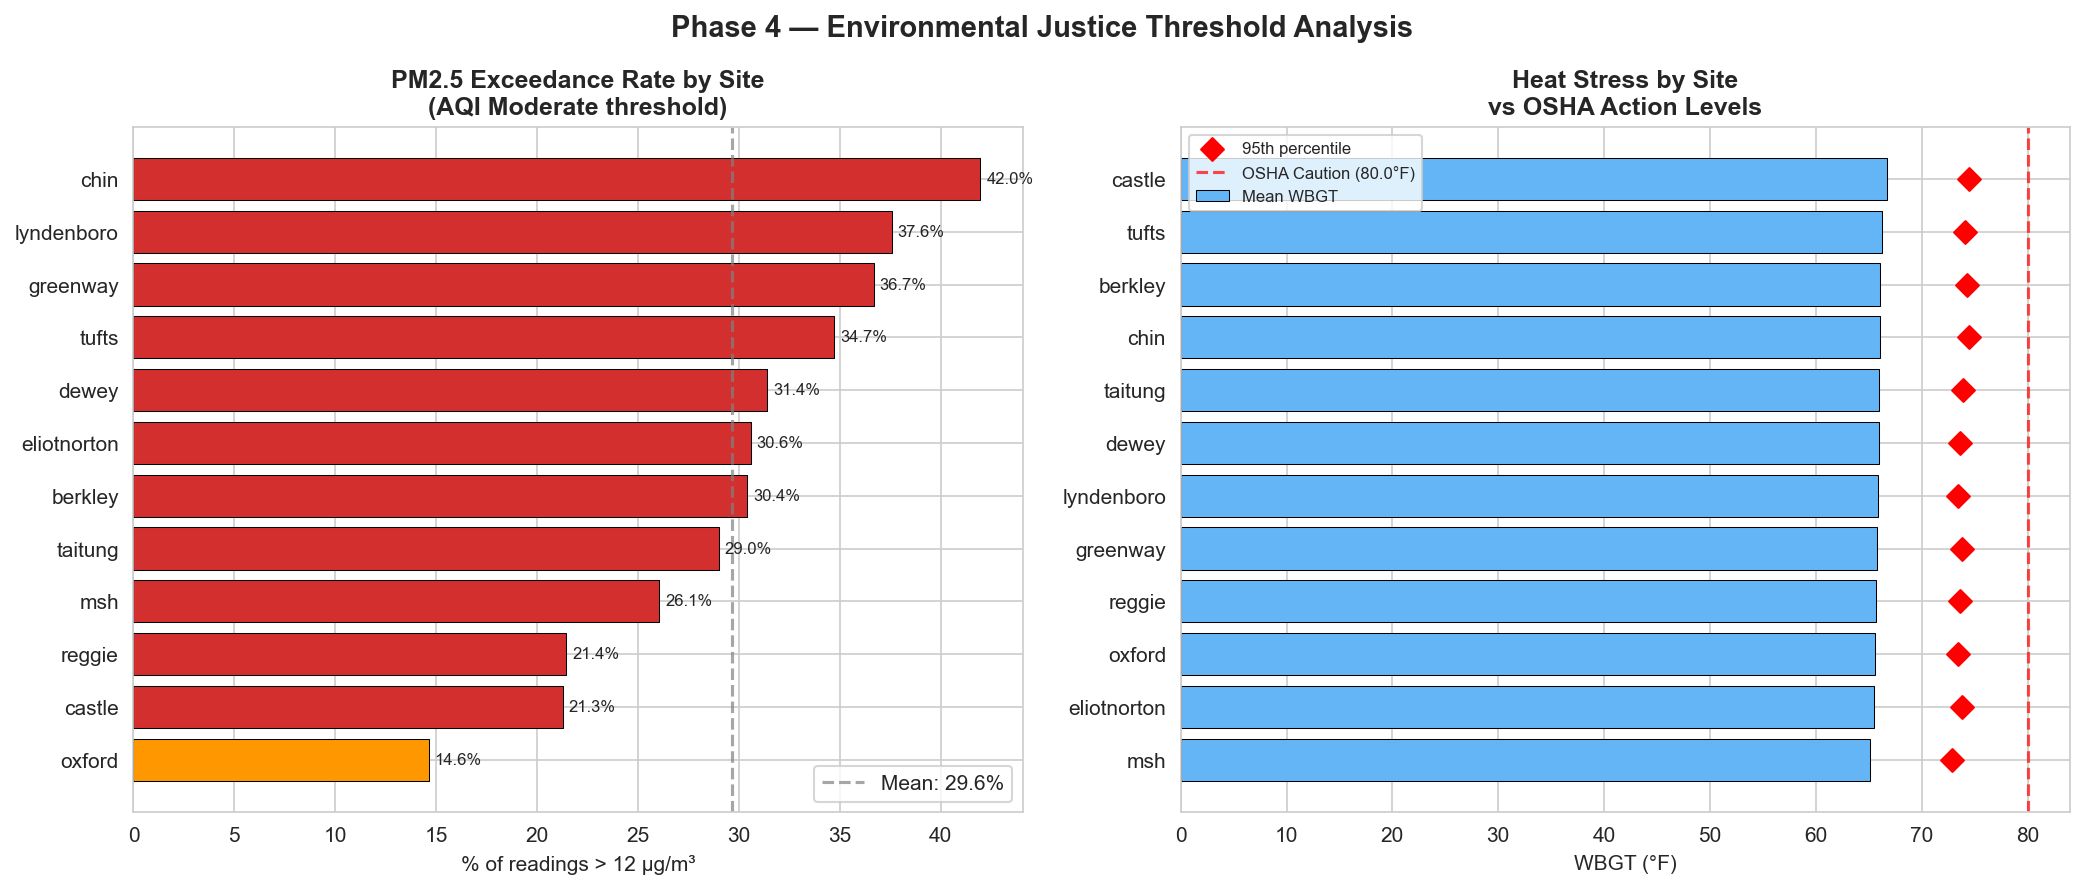


=== SITE-LEVEL DISPARITIES ===
PM2.5 inter-site range: 2.79 µg/m³
PM2.5 coefficient of variation: 10.1%
WBGT inter-site range: 1.67 °F
WBGT coefficient of variation: 0.6%
Highest PM2.5 site: greenway (10.7 µg/m³)
Lowest PM2.5 site:  oxford (7.9 µg/m³)
Highest WBGT site:  castle (66.8 °F)
Lowest WBGT site:   msh (65.1 °F)


In [11]:
# EJ Visualization: threshold exceedance by site
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PM2.5 exceedance by site
ax = axes[0]
site_pct_moderate = df.groupby('site_id')[PM].apply(lambda x: (x > EPA_AQI_MODERATE).mean() * 100)
site_pct_moderate = site_pct_moderate.sort_values(ascending=True)
colors_pm = ['#d32f2f' if v > 20 else '#ff9800' if v > 10 else '#4caf50' for v in site_pct_moderate]
ax.barh(site_pct_moderate.index, site_pct_moderate.values, color=colors_pm, edgecolor='black', linewidth=0.5)
ax.axvline(site_pct_moderate.mean(), ls='--', color='gray', alpha=0.7, label=f'Mean: {site_pct_moderate.mean():.1f}%')
ax.set_xlabel('% of readings > 12 µg/m³')
ax.set_title('PM2.5 Exceedance Rate by Site\n(AQI Moderate threshold)', fontweight='bold')
ax.legend()
for i, (sid, val) in enumerate(site_pct_moderate.items()):
    ax.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=8)

# WBGT distribution with thresholds
ax = axes[1]
site_means_wbgt = site_summary.wbgt_mean.sort_values(ascending=True)
site_p95_wbgt = site_summary.wbgt_p95.reindex(site_means_wbgt.index)

ax.barh(site_means_wbgt.index, site_means_wbgt.values, color='#64b5f6', 
        edgecolor='black', linewidth=0.5, label='Mean WBGT')
ax.scatter(site_p95_wbgt.values, range(len(site_p95_wbgt)), 
          color='red', s=60, zorder=5, marker='D', label='95th percentile')
ax.axvline(OSHA_CAUTION, ls='--', color='red', alpha=0.7, label=f'OSHA Caution ({OSHA_CAUTION}°F)')
ax.set_xlabel('WBGT (°F)')
ax.set_title('Heat Stress by Site\nvs OSHA Action Levels', fontweight='bold')
ax.legend(fontsize=8)

plt.suptitle('Phase 4 — Environmental Justice Threshold Analysis', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / 'p4_ej_thresholds.png', bbox_inches='tight')
plt.show()

# Summary KPIs for site-level EJ disparities
print('\n=== SITE-LEVEL DISPARITIES ===')
pm_range = site_summary.pm25_mean.max() - site_summary.pm25_mean.min()
wb_range = site_summary.wbgt_mean.max() - site_summary.wbgt_mean.min()
pm_cv = site_summary.pm25_mean.std() / site_summary.pm25_mean.mean() * 100
wb_cv = site_summary.wbgt_mean.std() / site_summary.wbgt_mean.mean() * 100

print(f'PM2.5 inter-site range: {pm_range:.2f} µg/m³')
print(f'PM2.5 coefficient of variation: {pm_cv:.1f}%')
print(f'WBGT inter-site range: {wb_range:.2f} °F')
print(f'WBGT coefficient of variation: {wb_cv:.1f}%')
print(f'Highest PM2.5 site: {site_summary.pm25_mean.idxmax()} ({site_summary.pm25_mean.max():.1f} µg/m³)')
print(f'Lowest PM2.5 site:  {site_summary.pm25_mean.idxmin()} ({site_summary.pm25_mean.min():.1f} µg/m³)')
print(f'Highest WBGT site:  {site_summary.wbgt_mean.idxmax()} ({site_summary.wbgt_mean.max():.1f} °F)')
print(f'Lowest WBGT site:   {site_summary.wbgt_mean.idxmin()} ({site_summary.wbgt_mean.min():.1f} °F)')

## 9. Phase 4 Synthesis

In [12]:
# Compile Phase 4 findings
print('=' * 70)
print('PHASE 4 — ADVANCED ANALYTICS: COMPREHENSIVE SUMMARY')
print('=' * 70)

print(f"""
1. K-MEANS CLUSTERING
   Optimal clusters: {optimal_k} (silhouette = {max(sil_scores):.3f})
   Features: {len(cluster_features)} (environmental + land-use)
   PCA variance explained: {pca.explained_variance_ratio_[:2].sum():.1%} (2 components)

2. REGRESSION DEEP-DIVE
   Quantile regression: WBGT effect varies across PM2.5 distribution
     - 50th quantile: {qr_results[0.50].params[WBGT]:.4f}
     - 95th quantile: {qr_results[0.95].params[WBGT]:.4f}
   Random Forest R² = {rf_r2:.3f}
   Top RF feature: {rf_labels[sorted_idx[0]]} (importance={importances[sorted_idx[0]]:.3f})

3. PRINCIPAL COMPONENT ANALYSIS
   PC1 ({pca_full.explained_variance_ratio_[0]:.1%}): Thermal comfort axis
   PC2 ({pca_full.explained_variance_ratio_[1]:.1%}): Air quality axis

4. SPATIAL ANALYSIS
   Interactive Folium map: {'Generated' if HAS_FOLIUM else 'Skipped (no folium)'}
   Static map generated with PM2.5 and WBGT coloring

5. CHANGE-POINT DETECTION
   PM2.5: {cp_date_pm.strftime('%Y-%m-%d')} (p={p_pm:.4f})
   WBGT:  {cp_date_wb.strftime('%Y-%m-%d')} (p={p_wb:.4f})

6. ANOMALY DETECTION
   Isolation Forest: {n_anomalies:,} anomalies ({n_anomalies/len(anom_df)*100:.1f}%)

7. SANKEY RANK DIAGRAM
   PM2.5 vs WBGT rank correlation: ρ = {rho:.3f} (p={p_rho:.4f})

8. ENVIRONMENTAL JUSTICE
   Sites exceeding NAAQS annual: {len(exceed_annual)} / 12
   OSHA heat thresholds exceeded: None (max WBGT = {max_wbgt:.1f} °F)
   Compound exposure risk: {compound_exposure:.2f}%
   PM2.5 inter-site disparity: {pm_range:.2f} µg/m³ ({pm_cv:.1f}% CV)

FIGURES GENERATED ({len(list(FIG_DIR.glob('*.png')))} PNG files):
""")

for f in sorted(FIG_DIR.glob('*.png')):
    print(f'  • {f.name}')
for f in sorted(FIG_DIR.glob('*.html')):
    print(f'  • {f.name}')

print(f'\nAll outputs saved to: {FIG_DIR}')

PHASE 4 — ADVANCED ANALYTICS: COMPREHENSIVE SUMMARY

1. K-MEANS CLUSTERING
   Optimal clusters: 4 (silhouette = 0.218)
   Features: 15 (environmental + land-use)
   PCA variance explained: 61.9% (2 components)

2. REGRESSION DEEP-DIVE
   Quantile regression: WBGT effect varies across PM2.5 distribution
     - 50th quantile: 0.5743
     - 95th quantile: 0.6489
   Random Forest R² = 0.740
   Top RF feature: Temperature (importance=0.271)

3. PRINCIPAL COMPONENT ANALYSIS
   PC1 (38.4%): Thermal comfort axis
   PC2 (29.0%): Air quality axis

4. SPATIAL ANALYSIS
   Interactive Folium map: Skipped (no folium)
   Static map generated with PM2.5 and WBGT coloring

5. CHANGE-POINT DETECTION
   PM2.5: 2023-08-18 (p=0.0990)
   WBGT:  2023-08-23 (p=0.4903)

6. ANOMALY DETECTION
   Isolation Forest: 926 anomalies (2.0%)

7. SANKEY RANK DIAGRAM
   PM2.5 vs WBGT rank correlation: ρ = 0.245 (p=0.4433)

8. ENVIRONMENTAL JUSTICE
   Sites exceeding NAAQS annual: 9 / 12
   OSHA heat thresholds exceeded: N